## Model Building

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", message=".*no associated frequency.*")

df2 = pd.read_csv("../datasets/eda_cleaned.csv", parse_dates=["date"])
df2["total"] = pd.to_numeric(df2["total"], errors="coerce")
df2 = df2.dropna(subset=["date", "total"]).sort_values("date").set_index("date")

print(f"Loaded {len(df2)} rows from ../datasets/eda_cleaned.csv")
print(f"Date range: {df2.index.min().date()} to {df2.index.max().date()}")


Loaded 949 rows from ../datasets/eda_cleaned.csv
Date range: 2022-12-22 to 2026-02-28


In [2]:
df3 = df2.copy()
df3.index = pd.to_datetime(df2.index)  
df3 = df3.sort_index()

In [3]:
df3.head(10)

,total,month,week,quarter,is_weekend,total:10_days_rolling,total:30_days_rolling,total:50_days_rolling,is_closed,is_suspicious_zero,store_open,weekly_total_diff,day_of_week,month_name,week_of_year,is_holiday,days_to_next_holiday,lag_1,lag_7,lag_14
date,,,,,,,,,,,,,,,,,,,,
2022-12-22,1126.0,12,51,4,0,383.2,292.966667,257.12,False,False,1,901.0,Thursday,December,51,0,3,605.0,225.0,116.0
2022-12-23,1266.0,12,51,4,0,475.1,329.300000,276.70,False,False,1,761.0,Friday,December,51,0,2,1126.0,505.0,280.0
2022-12-24,1470.0,12,51,4,1,581.7,369.833333,300.40,False,False,1,720.0,Saturday,December,51,0,1,1266.0,750.0,335.0
2022-12-25,0.0,12,51,4,1,715.7,415.666667,329.44,True,False,0,-437.0,Sunday,December,51,1,0,1470.0,437.0,559.0
2022-12-26,424.0,12,52,4,0,693.2,392.666667,328.90,False,False,1,174.0,Monday,December,52,1,0,0.0,250.0,207.0
2022-12-27,320.0,12,52,4,0,685.1,393.766667,332.18,False,False,1,-203.0,Tuesday,December,52,0,5,424.0,523.0,200.0
2022-12-28,556.0,12,52,4,0,642.1,396.666667,336.96,False,False,1,-49.0,Wednesday,December,52,0,4,320.0,605.0,130.0
2022-12-29,425.0,12,52,4,0,654.0,407.566667,341.96,False,False,1,-701.0,Thursday,December,52,0,3,556.0,1126.0,225.0
2022-12-30,624.0,12,52,4,0,671.5,417.733333,348.00,False,False,1,-642.0,Friday,December,52,0,2,425.0,1266.0,505.0


In [4]:
df3.index.min()

Timestamp('2022-12-22 00:00:00')

In [5]:
df3.index.max()

Timestamp('2026-02-28 00:00:00')

In [6]:
df2.isna().sum()

total                    0
month                    0
week                     0
quarter                  0
is_weekend               0
total:10_days_rolling    0
total:30_days_rolling    0
total:50_days_rolling    0
is_closed                0
is_suspicious_zero       0
store_open               0
weekly_total_diff        0
day_of_week              0
month_name               0
week_of_year             0
is_holiday               0
days_to_next_holiday     0
lag_1                    0
lag_7                    0
lag_14                   0
dtype: int64

In [23]:
df3.columns

Index(['total', 'month', 'week', 'quarter', 'is_weekend',
       'total_10_days_rolling', 'total_30_days_rolling',
       'total_50_days_rolling', 'is_closed', 'is_suspicious_zero',
       'store_open', 'weekly_total_diff', 'day_of_week', 'month_name',
       'week_of_year', 'is_holiday', 'days_to_next_holiday', 'lag_1', 'lag_7',
       'lag_14'],
      dtype='object')

In [25]:
drop_cols = [
    # "day",
    # "time",
    "day_of_week",
    "month_name",
    # "total_employees_hours",
    # "total_employees",
    # "total_tips",
    "weekly_total_diff",
    # "is_future"
]

df3 = df3.drop(columns=drop_cols)

In [26]:
df3 = df3.dropna()

In [27]:
df3.isna().sum()

total                    0
month                    0
week                     0
quarter                  0
is_weekend               0
total_10_days_rolling    0
total_30_days_rolling    0
total_50_days_rolling    0
is_closed                0
is_suspicious_zero       0
store_open               0
week_of_year             0
is_holiday               0
days_to_next_holiday     0
lag_1                    0
lag_7                    0
lag_14                   0
dtype: int64

In [28]:
X = df3.drop(columns=["total"])
y = df3["total"]

In [29]:
df3.index.min(), df3.index.max(), len(df3)

(Timestamp('2022-12-22 00:00:00'), Timestamp('2026-02-28 00:00:00'), 949)

In [30]:
df3.columns = df3.columns.str.replace(":", "_")

In [31]:
df3.columns

Index(['total', 'month', 'week', 'quarter', 'is_weekend',
       'total_10_days_rolling', 'total_30_days_rolling',
       'total_50_days_rolling', 'is_closed', 'is_suspicious_zero',
       'store_open', 'week_of_year', 'is_holiday', 'days_to_next_holiday',
       'lag_1', 'lag_7', 'lag_14'],
      dtype='object')

In [32]:
df_model = df3.sort_index()

## Model1: Light GBM

**Time-Based Split**

- We'll split like this:
    - Train: 2022-11-15 → 2024-12-31
    - Val:   2025-01-01 → 2025-09-30
    - Test:  2025-10-01 → 2026-02-28

In [33]:
train = df_model.loc[:'2024-12-31']
val   = df_model.loc['2025-01-01':'2025-09-30']
test  = df_model.loc['2025-10-01':]

In [34]:
X_train = train.drop(columns=["total"])
y_train = train["total"]  

X_val = val.drop(columns=["total"])
y_val = val["total"]

X_test = test.drop(columns=["total"])
y_test = test["total"]

**Build a Baseline Model**

In [35]:
naive_pred = y_test.shift(1)

mae_naive = np.mean(np.abs(y_test[1:] - naive_pred[1:]))

print("Naive MAE:", mae_naive)

Naive MAE: 273.4066666666667


In [36]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1199
[LightGBM] [Info] Number of data points in the train set: 526, number of used features: 13
[LightGBM] [Info] Start training from score 375.757852
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=500,
              random_state=42)

In [37]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

In [ ]:
mae_val = np.mean(np.abs(val["total"] - val_pred))
mae_test = np.mean(np.abs(test["total"] - test_pred))

print("Validation MAE:", mae_val)
print("Test MAE:", mae_test)

Validation MAE: 231.27629770088905
Test MAE: 238.88750515822815


In [39]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False)

lag_7                    828
lag_14                   567
total_30_days_rolling    520
lag_1                    516
total_10_days_rolling    504
total_50_days_rolling    479
days_to_next_holiday     279
week                     254
is_holiday                63
is_weekend                35
month                     33
quarter                    0
is_closed                  0
is_suspicious_zero         0
store_open                 0
week_of_year               0
dtype: int32

In [40]:
# Forecast Function
import holidays
us_holidays = holidays.US()

future_days = 7
forecast_df = df_model.copy()

predictions = []

for i in range(future_days):

    last_date = forecast_df.index[-1]
    next_date = last_date + pd.Timedelta(days=1)

    new_row = {}

    new_row["month"] = next_date.month
    new_row["week"] = next_date.isocalendar().week
    new_row["year"] = next_date.year
    new_row["quarter"] = next_date.quarter
    new_row["is_weekend"] = int(next_date.weekday() >= 5)

    # holiday features
    new_row["is_holiday"] = int(next_date.date() in us_holidays)

    new_row["days_to_next_holiday"] = min(
        [(h - next_date.date()).days for h in us_holidays if (h - next_date.date()).days >= 0] + [365]
    )

    # lag features
    new_row["lag_1"] = forecast_df["total"].iloc[-1]
    new_row["lag_7"] = forecast_df["total"].iloc[-7]
    new_row["lag_14"] = forecast_df["total"].iloc[-14]

    # rolling features
    new_row["total_10_days_rolling"] = forecast_df["total"].tail(10).mean()
    new_row["total_30_days_rolling"] = forecast_df["total"].tail(30).mean()
    new_row["total_50_days_rolling"] = forecast_df["total"].tail(50).mean()

    new_row["week_of_year"] = next_date.isocalendar().week
    new_row["store_open"] = 1
    new_row["is_closed"] = 0
    new_row["is_suspicious_zero"] = 0

    new_row = pd.DataFrame([new_row], index=[next_date])

    X_new = new_row[X_train.columns]
    pred = model.predict(X_new)[0]

    new_row["total"] = pred

    forecast_df = pd.concat([forecast_df, new_row])

    predictions.append(pred)

In [41]:
forecast_index = pd.date_range(
    df_model.index[-1] + pd.Timedelta(days=1),
    periods=7
)

forecast_series = pd.Series(predictions, index=forecast_index)

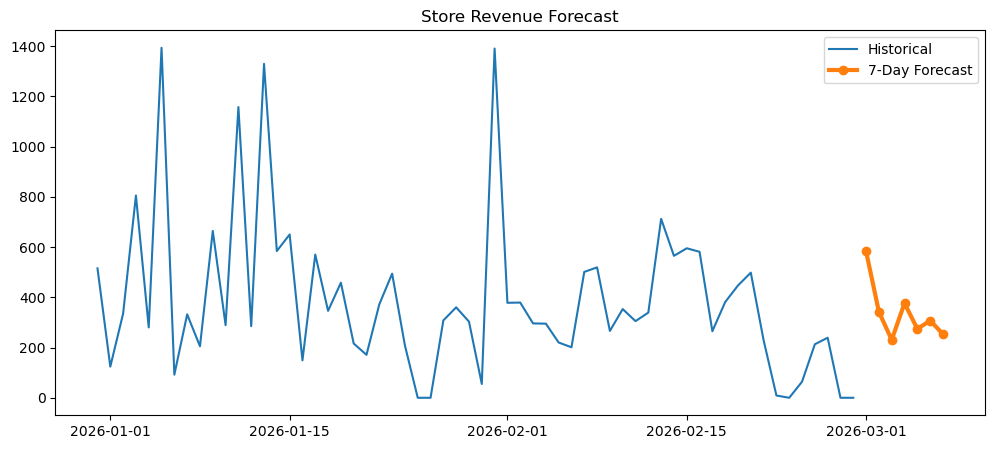

In [42]:
plt.figure(figsize=(12,5))

plt.plot(df_model["total"].tail(60), label="Historical")

plt.plot(
    forecast_series,
    marker="o",
    linewidth=3,
    label="7-Day Forecast"
)

plt.legend()
plt.title("Store Revenue Forecast")
plt.show()

In [43]:
df_model["total"].tail(14)

date
2026-02-15    595.0
2026-02-16    581.0
2026-02-17    265.0
2026-02-18    381.0
2026-02-19    447.0
2026-02-20    498.0
2026-02-21    229.0
2026-02-22      9.0
2026-02-23      0.0
2026-02-24     64.0
2026-02-25    213.0
2026-02-26    239.0
2026-02-27      0.0
2026-02-28      0.0
Name: total, dtype: float64

In [44]:
lag7_compare = pd.DataFrame({
    "lag_7_value": df_model["total"].iloc[-7:].values,
    "forecast": forecast_series.values
})

lag7_compare

,lag_7_value,forecast
0,9.0,582.619868
1,0.0,341.991321
2,64.0,230.538532
3,213.0,376.471535
4,239.0,273.915203
5,0.0,307.234236
6,0.0,253.613768


In [45]:
df_model["total"].describe()

count     949.000000
mean      410.294658
std       318.674339
min         0.000000
25%       210.000000
50%       339.000000
75%       513.000000
max      2822.000000
Name: total, dtype: float64

In [46]:
df_model[df_model["total"] == 0].shape

(16, 17)

In [47]:
# We wil add day of the week feature to our dataset
df_model["day_of_week"] = df_model.index.dayofweek

In [48]:
# Recreate Splits

train = df_model.loc[:'2024-12-31']
val   = df_model.loc['2025-01-01':'2025-09-30']
test  = df_model.loc['2025-10-01':]

In [49]:
# Recreate Features
X_train = train.drop(columns=["total"])
y_train = train["total"]

X_val = val.drop(columns=["total"])
y_val = val["total"]

X_test = test.drop(columns=["total"])
y_test = test["total"]

In [50]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1206
[LightGBM] [Info] Number of data points in the train set: 526, number of used features: 14
[LightGBM] [Info] Start training from score 375.757852
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=500,
              random_state=42)

In [51]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("Validation MAE:", np.mean(np.abs(y_val - val_pred)))
print("Test MAE:", np.mean(np.abs(y_test - test_pred)))

Validation MAE: 219.66598536675485
Test MAE: 241.95376388649908


## Model 2: Ridge Regression

In [57]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=8.286427728546842)

ridge.fit(X_train, y_train)

val_pred = ridge.predict(X_val)
test_pred = ridge.predict(X_test)

print("Ridge Validation MAE:", np.mean(np.abs(y_val - val_pred)))
print("Ridge Test MAE:", np.mean(np.abs(y_test - test_pred)))


Ridge Validation MAE: 193.98526660520935
Ridge Test MAE: 230.6434365816551


## Model3: Random Forest

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("RF Validation MAE:", np.mean(np.abs(y_val - val_pred)))
print("RF Test MAE:", np.mean(np.abs(y_test - test_pred)))

RF Validation MAE: 200.2546386695143
RF Test MAE: 240.3920300759692


In [ ]:
pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

In [ ]:
df_model.columns

In [55]:
# Ridge Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
import numpy as np

ridge = Ridge()

param_grid = {
    "alpha": np.logspace(-3, 3, 50)
}

grid = GridSearchCV(
    ridge,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5
)

grid.fit(X_train, y_train)

best_ridge = grid.best_estimator_

print("Best alpha:", grid.best_params_)

Best alpha: {'alpha': 8.286427728546842}


In [56]:
val_pred = best_ridge.predict(X_val)
test_pred = best_ridge.predict(X_test)

print("Validation MAE:", np.mean(np.abs(y_val - val_pred)))
print("Test MAE:", np.mean(np.abs(y_test - test_pred)))

Validation MAE: 193.98526660520935
Test MAE: 230.6434365816551


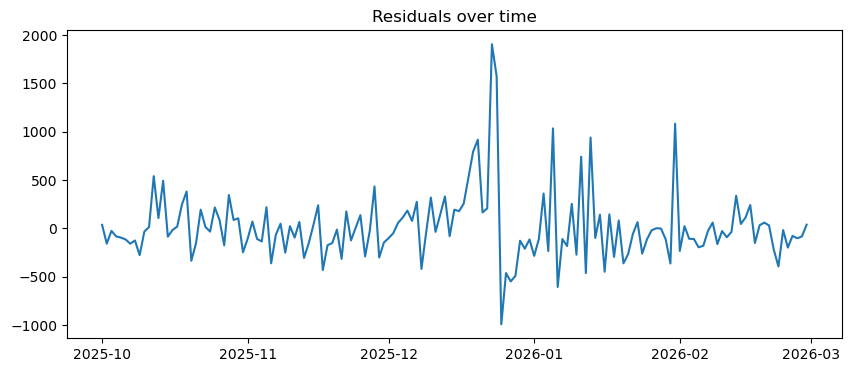

In [58]:
test_pred = best_ridge.predict(X_test)
residuals = y_test - test_pred

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

In [59]:
residuals.describe()

count     151.000000
mean       12.516405
std       358.334467
min      -992.664334
25%      -158.946979
50%       -33.937242
75%       111.810040
max      1904.391024
Name: total, dtype: float64

## Since Ridge Regression is performing better than Light GBM and Random Foreset we will finalize Ridge as our Final Model.

In [60]:
# Train final Ridge model on all historical data

final_model = Ridge(alpha=8.286427728546842)

X_all = df_model.drop(columns=["total"])
y_all = df_model["total"]

final_model.fit(X_all, y_all)

Ridge(alpha=8.286427728546842)

In [62]:
# Build recursive 7-day forecast
forecast_df = df_model.copy()
future_predictions = []

for _ in range(7):
    last_date = forecast_df.index[-1]
    next_date = last_date + pd.Timedelta(days=1)

    new_row = {}

    # calendar features
    new_row["month"] = next_date.month
    new_row["week"] = int(next_date.isocalendar().week)
    new_row["year"] = next_date.year
    new_row["quarter"] = next_date.quarter
    new_row["is_weekend"] = int(next_date.weekday() >= 5)
    new_row["week_of_year"] = int(next_date.isocalendar().week)
    new_row["day_of_week"] = next_date.weekday()

    # holiday features
    is_hol = int(next_date.date() in us_holidays)
    new_row["is_holiday"] = is_hol

    holiday_dates = pd.to_datetime(list(us_holidays.keys()))
    future_holidays = holiday_dates[holiday_dates >= pd.Timestamp(next_date)]
    if len(future_holidays) == 0:
        new_row["days_to_next_holiday"] = 365
    else:
        new_row["days_to_next_holiday"] = (future_holidays.min() - pd.Timestamp(next_date)).days

    # store status
    if is_hol == 1:
        new_row["store_open"] = 0
        new_row["is_closed"] = 1
    else:
        new_row["store_open"] = 1
        new_row["is_closed"] = 0

    new_row["is_suspicious_zero"] = 0

    # lag features
    new_row["lag_1"] = forecast_df["total"].iloc[-1]
    new_row["lag_7"] = forecast_df["total"].iloc[-7]
    new_row["lag_14"] = forecast_df["total"].iloc[-14]

    # rolling features
    new_row["total_10_days_rolling"] = forecast_df["total"].iloc[-10:].mean()
    new_row["total_30_days_rolling"] = forecast_df["total"].iloc[-30:].mean()
    new_row["total_50_days_rolling"] = forecast_df["total"].iloc[-50:].mean()

    # make dataframe in exact training column order
    new_row_df = pd.DataFrame([new_row], index=[next_date])
    new_row_df = new_row_df.reindex(columns=X_all.columns)

    # predict
    pred = final_model.predict(new_row_df)[0]

    # add prediction back
    new_row_df["total"] = pred
    forecast_df = pd.concat([forecast_df, new_row_df])

    future_predictions.append(pred)

In [63]:
# Build recursive 7-day forecast
forecast_index = pd.date_range(
    start=df_model.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

forecast_series = pd.Series(future_predictions, index=forecast_index)
print(forecast_series)

2026-03-01    193.827065
2026-03-02    158.979287
2026-03-03    147.098075
2026-03-04    169.223858
2026-03-05    188.321140
2026-03-06    190.291420
2026-03-07    203.632267
Freq: D, dtype: float64


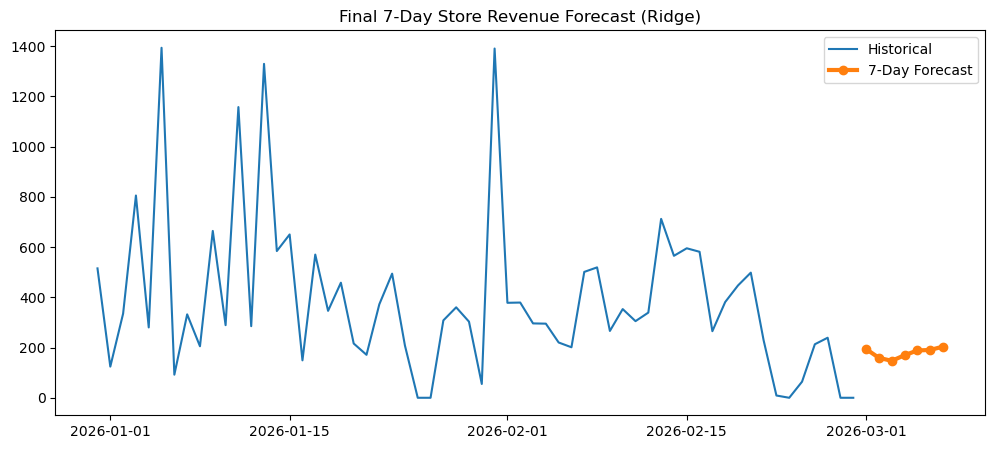

In [64]:
plt.figure(figsize=(12,5))
plt.plot(df_model["total"].tail(60), label="Historical")
plt.plot(forecast_series, marker="o", linewidth=3, label="7-Day Forecast")
plt.legend()
plt.title("Final 7-Day Store Revenue Forecast (Ridge)")
plt.show()